# Imports

In [74]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from cellpose import models
from skimage import measure
from skimage.measure import regionprops
import cv2
from scipy.spatial import cKDTree

# Upload Image

- Using SEM images with 50,000 magnification
- 3 images per treatment

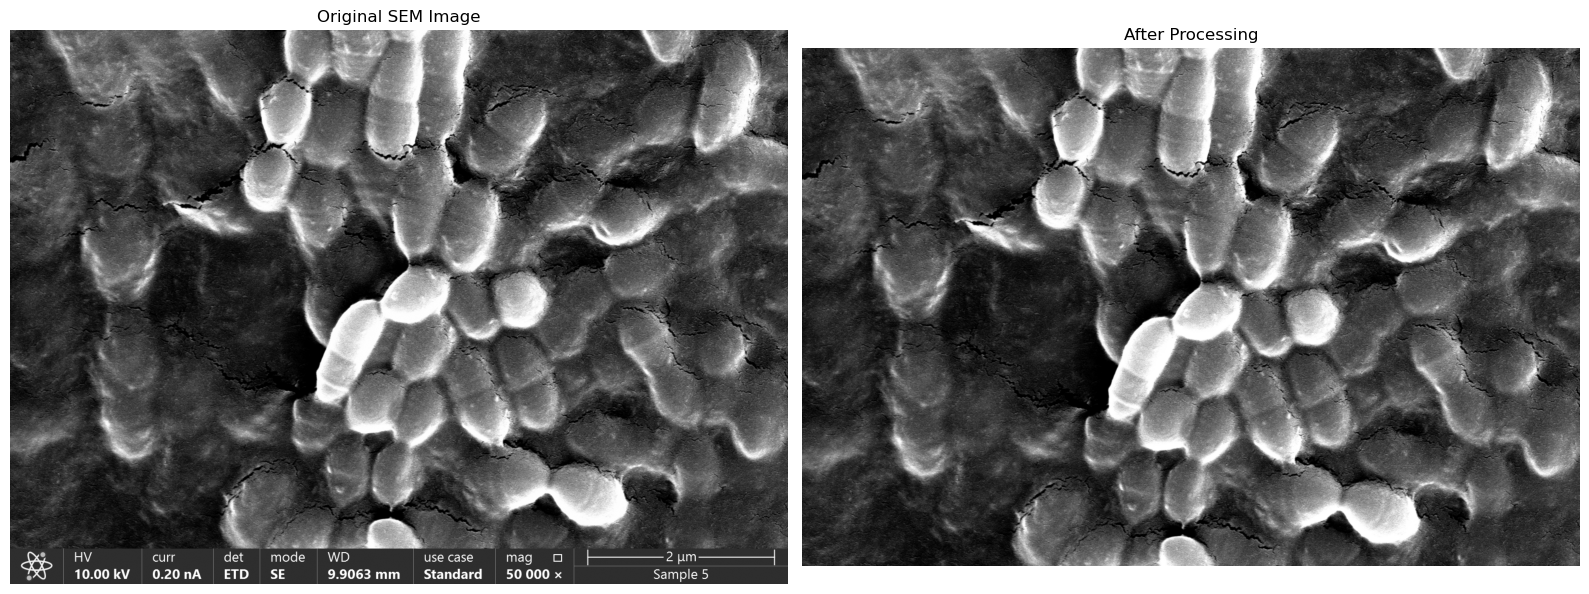

In [75]:
IMAGE_PATH = "./data/6.25 ug:ml/50000/Sample 5_05.tif"   

original_image = np.array(Image.open(IMAGE_PATH).convert("L"))

height, width = original_image.shape

image = original_image[:height - 70, :]

# Display both original and cropped for comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].imshow(original_image, cmap='gray')
axes[0].set_title('Original SEM Image')
axes[0].axis('off')

axes[1].imshow(image, cmap='gray')
axes[1].set_title('After Processing')
axes[1].axis('off')

plt.tight_layout()
plt.show()

# Segmentation

Estimated diameter: 89.1 px
Detected 72 bacteria


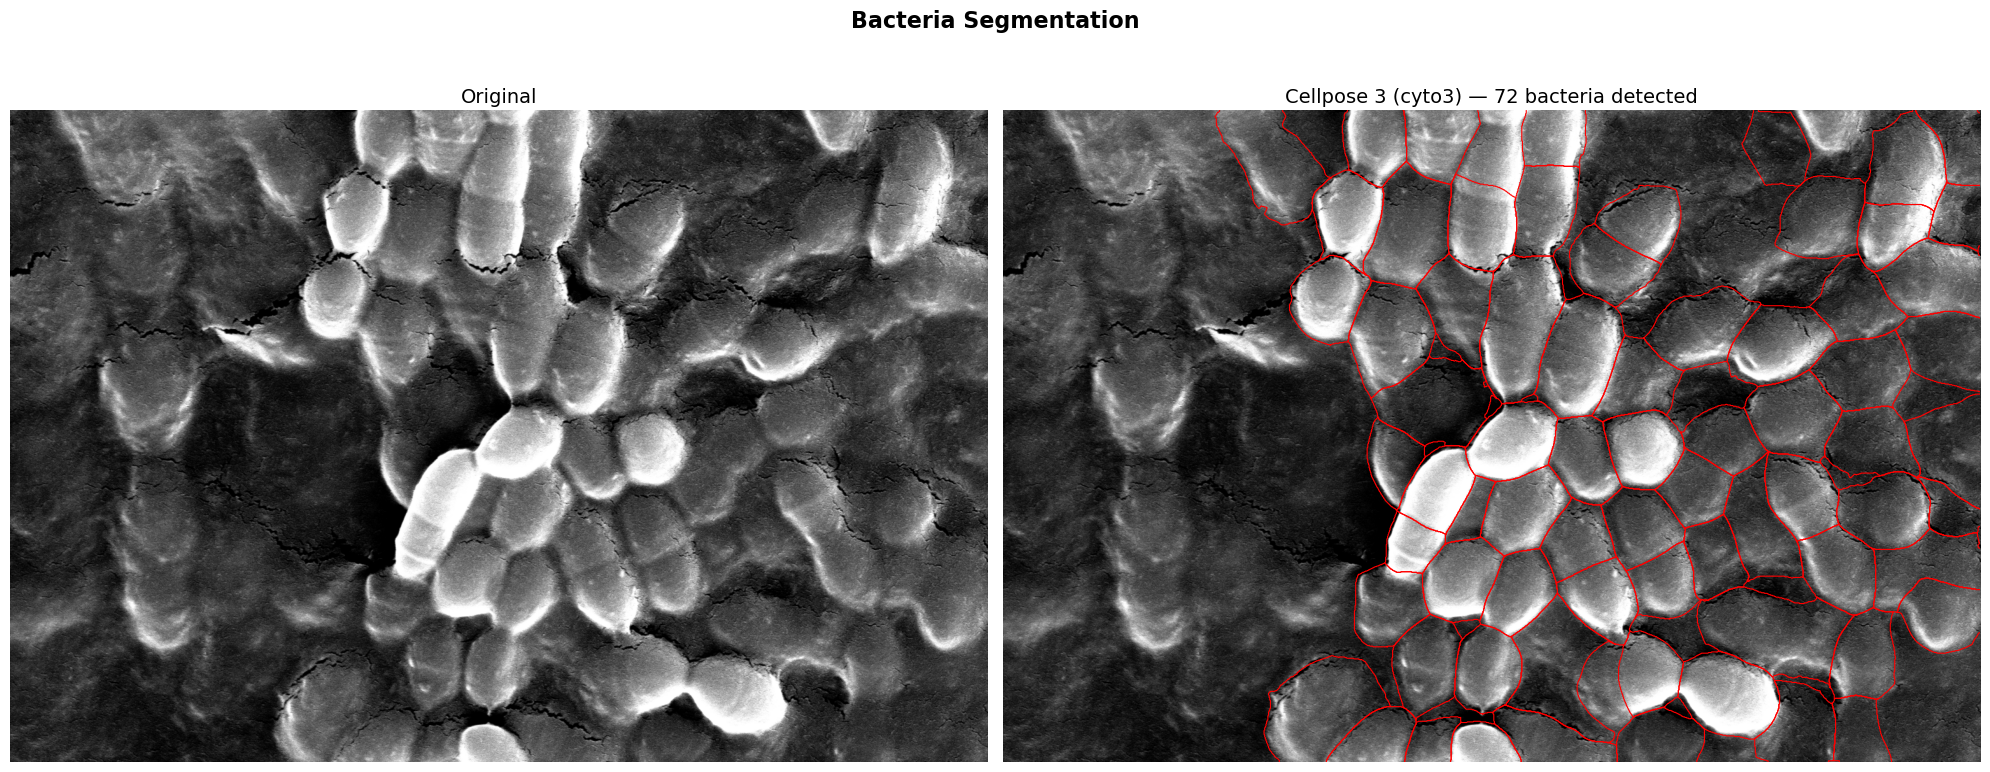

In [76]:
MODEL_TYPE   = "cyto3"
FLOW_THRESH  = 0.4       
CELLPROB_THRESH = -2.0   
DIAMETER = None          

def run_segmentation(img):
 
    model = models.Cellpose(model_type="cyto3", gpu=False)
    masks, _, _, diams = model.eval(
        img,
        diameter=DIAMETER,
        channels=[0, 0],
        flow_threshold=FLOW_THRESH,
        cellprob_threshold=CELLPROB_THRESH,
    )
    print(f"Estimated diameter: {diams:.1f} px")
 
    print(f"Detected {masks.max()} bacteria")
    return masks
 
 
def visualize(img, masks):
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
 
    axes[0].imshow(img, cmap="gray")
    axes[0].set_title("Original", fontsize=14)
    axes[0].axis("off")
 
    axes[1].imshow(img, cmap="gray")
    for region in measure.regionprops(masks):
        cell_mask = (masks == region.label).astype(np.uint8)
        contours = measure.find_contours(cell_mask, 0.5)
        for contour in contours:
            axes[1].plot(contour[:, 1], contour[:, 0], linewidth=0.8, color="red")
 
    n_cells = masks.max()
    axes[1].set_title(f"Cellpose 3 (cyto3) — {n_cells} bacteria detected", fontsize=14)
    axes[1].axis("off")
 
    plt.suptitle("Bacteria Segmentation", fontsize=16, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show() 

masks = run_segmentation(image)
visualize(image, masks)

# Make List

In [77]:
def compute_ellipse_fit_score(contour, mask_shape):
    """
    Fit an ellipse to the contour and return IoU between
    the actual mask and the ideal fitted ellipse mask.
    Score = 1.0 means perfect ellipse; lower = more irregular / occluded.
    """
    if len(contour) < 5:
        return 0.0

    ellipse = cv2.fitEllipse(contour)
    ellipse_mask = np.zeros(mask_shape, dtype=np.uint8)
    cv2.ellipse(ellipse_mask, ellipse, 1, -1)

    actual_mask = np.zeros(mask_shape, dtype=np.uint8)
    cv2.drawContours(actual_mask, [contour], -1, 1, -1)

    intersection = np.logical_and(actual_mask, ellipse_mask).sum()
    union = np.logical_or(actual_mask, ellipse_mask).sum()
    return float(intersection / union) if union > 0 else 0.0


def is_touching_border(contour, mask_shape, margin=1):
    """Return True if any contour point is within `margin` pixels of the image edge."""
    h, w = mask_shape
    pts = contour.reshape(-1, 2)  # shape (N, 2): col, row
    return bool(
        np.any(pts[:, 0] <= margin) or       # left edge
        np.any(pts[:, 1] <= margin) or        # top edge
        np.any(pts[:, 0] >= w - 1 - margin) or  # right edge
        np.any(pts[:, 1] >= h - 1 - margin)     # bottom edge
    )


def extract_bacteria_features(mask: np.ndarray) -> list[dict]:
    """Extract features for all bacteria in mask."""
    bacteria_list = []
    min_area = 4000
    mask_shape = mask.shape

    for prop in regionprops(mask):
        if prop.area < min_area:
            continue

        individual_mask = (mask == prop.label).astype(np.uint8)
        contours, _ = cv2.findContours(individual_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if len(contours) == 0 or len(contours[0]) < 5:
            continue

        contour = contours[0]
        major_px = prop.major_axis_length / 2
        minor_px = prop.minor_axis_length / 2

        perimeter = cv2.arcLength(contour, True)
        circularity = (4 * np.pi * prop.area / (perimeter ** 2)) if perimeter > 0 else 0.0
        ellipse_fit_score = compute_ellipse_fit_score(contour, mask_shape)
        touches_border = is_touching_border(contour, mask_shape)

        ratio = 5.0 / 370

        bacteria_list.append({
            'bacteria_id': prop.label,
            'contour': contour,
            'center': (int(prop.centroid[1]), int(prop.centroid[0])),
            'major_radius_pixels': major_px,
            'minor_radius_pixels': minor_px,
            'major_radius': major_px * ratio,
            'minor_radius': minor_px * ratio,
            'area': prop.area * ratio * ratio,
            'aspect_ratio': major_px / minor_px if minor_px > 0 else float('inf'),
            'circularity': circularity,
            'ellipse_fit_score': ellipse_fit_score,
            'touches_border': touches_border,
        })

    return bacteria_list

org_list = extract_bacteria_features(masks)

# Filter Bacteria 

filter bacteria that is hidden my other bacteria 

 - *removed_occluded* ellipse_fit_score fits an ellipse to the contour with cv2.fitEllipse, then computes IoU between the actual mask and the ideal ellipse. A full, round bacterium scores ~0.85–0.95. A partially hidden one (like your red examples) will score lower because a chunk of the ellipse is "missing".

 - *removed_border* — clipped by the image edge


In [78]:
def filter_bacteria_by_shape(
    bacteria_list: list[dict],
    min_ellipse_fit: float = 0.75,
) -> tuple[list[dict], list[dict], dict]:
    """
    Filter out bacteria that are:
      - not well-described by an ellipse (occluded by neighbors), OR
      - cut off by the image border
    """
    kept, removed = [], []
    for b in bacteria_list:
        if b['ellipse_fit_score'] >= min_ellipse_fit and not b['touches_border']:
            kept.append(b)
        else:
            removed.append(b)

    stats = {
        'total': len(bacteria_list),
        'kept': len(kept),
        'removed': len(removed),
        'removed_occluded': sum(1 for b in removed if not b['touches_border']),
        'removed_border': sum(1 for b in removed if b['touches_border']),
    }
    return kept, removed, stats


bacteria_list, removed_bacteria, filter_stats = filter_bacteria_by_shape(
    org_list,
    min_ellipse_fit=0.75,
)
print(filter_stats)

{'total': 63, 'kept': 42, 'removed': 21, 'removed_occluded': 3, 'removed_border': 18}


(np.float64(-0.5), np.float64(1535.5), np.float64(1023.5), np.float64(-0.5))

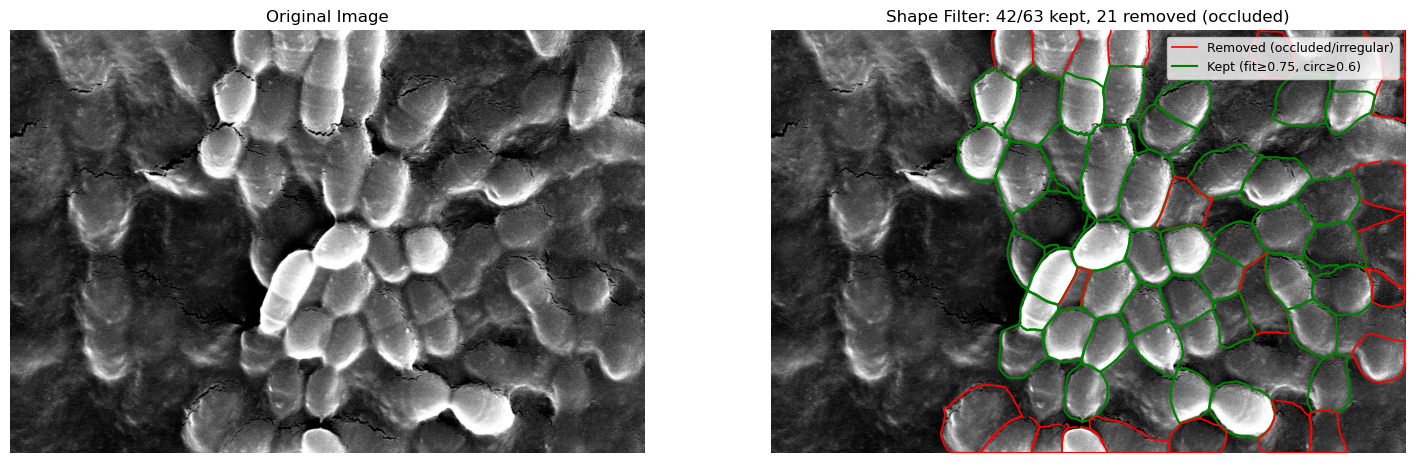

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].imshow(image, cmap='gray')
axes[0].set_title('Original Image', fontsize=12)
axes[0].axis('off')

axes[1].imshow(image, cmap='gray')

kept_ids = set(id(b) for b in bacteria_list)
kept_plotted = deleted_plotted = False

for bacteria in org_list:
    contour = bacteria['contour'].squeeze()
    if contour.ndim == 1:
        contour = contour[np.newaxis, :]

    is_kept = id(bacteria) in kept_ids
    color = 'g' if is_kept else 'r'
    lw = 1.5 if is_kept else 1.2

    label = None
    if is_kept and not kept_plotted:
        label = f'Kept (fit≥0.75, circ≥0.6)'
        kept_plotted = True
    elif not is_kept and not deleted_plotted:
        efs = bacteria['ellipse_fit_score']
        circ = bacteria['circularity']
        label = f'Removed (occluded/irregular)'
        deleted_plotted = True

    axes[1].plot(contour[:, 0], contour[:, 1], color=color, linewidth=lw, label=label)

n_total = len(org_list)
n_kept = len(bacteria_list)
axes[1].set_title(
    f'Shape Filter: {n_kept}/{n_total} kept, {n_total - n_kept} removed (occluded)',
    fontsize=12
)
axes[1].legend(loc='upper right', fontsize=9)
axes[1].axis('off')